
# Practical 19: Object Tracking & Counting (Classical CV)


> In this practical you’ll build an end‑to‑end mini pipeline for multi-object tracking and counting using only classical CV:
> 1) Generate a tiny synthetic video (moving circles).  
> 2) Detect objects with background subtraction.  
> 3) Track objects across frames with a lightweight IoU-based tracker (IDs).  
> 4) Count objects crossing a virtual line.  
> 5) Evaluate your result against ground truth.

**Why now?**  
You’ve already learned how to build and train CNNs and explored famous architectures (Prac. 7–18).  
Tracking & counting connects vision with temporal reasoning, preparing you for detection+tracking (Prac. 20) and segmentation (Prac. 21).

---

## Learning Objectives
- Explain detection vs. tracking and why IDs matter.
- Use background subtraction for moving-object detection.
- Implement a centroid/IoU-based multi-object tracker with basic data association.
- Draw a counting line/region and count objects that cross it in a direction.
- Compute simple metrics (counting error).


## 1) Setup & Imports

We’ll use OpenCV, NumPy and Matplotlib.

In [1]:

import os, math, json, csv, random, time, collections
from dataclasses import dataclass, field
from typing import List, Tuple, Dict

import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline
print("OpenCV version:", cv2.__version__)


OpenCV version: 4.12.0



## 2) Create a Tiny Synthetic Video (with ground truth)

We generate a short video of moving circles and record ground-truth IDs and positions per frame.
A vertical counting line is placed at the middle of the frame (count left ➜ right crossings).


In [2]:

def generate_synthetic_video(
    path="synthetic_demo.mp4",
    W=640, H=360, T=300,   # width, height, frames
    N=5,                   # number of moving objects
    r_range=(10, 18),      # circle radius range
    v_range=(2, 5),        # pixel/frame speed range
    seed=42,
    fps=30,
):
    random.seed(seed)
    np.random.seed(seed)

    objs = []
    for i in range(N):
        r = random.randint(*r_range)
        x = random.randint(r+2, W-r-2)
        y = random.randint(r+2, H-r-2)
        vx = random.choice([-1, 1]) * random.randint(*v_range)
        vy = random.choice([-1, 1]) * random.randint(*v_range)
        objs.append({"id": i, "x": x, "y": y, "vx": vx, "vy": vy, "r": r})

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(path, fourcc, fps, (W, H))

    line_x = W // 2
    gt_positions = {}
    gt_crossings = {i: 0 for i in range(N)}
    prev_side = {i: -1 if objs[i]["x"] < line_x else +1 for i in range(N)}

    for t in range(T):
        frame = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.line(frame, (line_x, 0), (line_x, H-1), (50, 50, 50), 1)

        for o in objs:
            o["x"] += o["vx"]
            o["y"] += o["vy"]
            if o["x"] - o["r"] <= 0 or o["x"] + o["r"] >= W:
                o["vx"] *= -1
            if o["y"] - o["r"] <= 0 or o["y"] + o["r"] >= H:
                o["vy"] *= -1
            cv2.circle(frame, (int(o["x"]), int(o["y"])), o["r"], (180, 180, 180), -1)

        writer.write(frame)

        gt_positions[t] = [(o["id"], float(o["x"]), float(o["y"]), float(o["r"])) for o in objs]

        for o in objs:
            side = -1 if o["x"] < line_x else +1
            if prev_side[o["id"]] == -1 and side == +1:
                gt_crossings[o["id"]] += 1
            prev_side[o["id"]] = side

    writer.release()

    with open("gt_positions.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["frame", "id", "x", "y", "r"])
        for t, rows in gt_positions.items():
            for (oid, x, y, r) in rows:
                w.writerow([t, oid, x, y, r])

    with open("gt_crossings.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["id", "left_to_right_crossings"])
        for oid, c in gt_crossings.items():
            w.writerow([oid, c])

    return {"video_path": path, "W": W, "H": H, "T": T, "N": N, "line_x": line_x,
            "gt_positions": gt_positions, "gt_crossings": gt_crossings}

gt = generate_synthetic_video()
gt["video_path"], gt["W"], gt["H"], gt["T"], gt["N"], gt["line_x"], sum(gt["gt_crossings"].values())


('synthetic_demo.mp4', 640, 360, 300, 5, 320, 5)

Let’s preview a few frames.


## 3) Motion Detection via Background Subtraction (MOG2)

Pipeline per frame:
1) Foreground mask  
2) Morphology (clean-up)  
3) Contours ➜ bounding boxes


In [4]:

def detect_moving_objects_mog2(video_path, min_area=80):
    cap = cv2.VideoCapture(video_path)
    fgbg = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=25, detectShadows=True)
    detections_per_frame = []
    kernel = np.ones((3,3), np.uint8)

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        mask = fgbg.apply(frame)
        _, mask_bin = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY)
        mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel, iterations=2)
        mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel, iterations=2)
        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        boxes = []
        for c in contours:
            if cv2.contourArea(c) < min_area:
                continue
            x,y,w,h = cv2.boundingRect(c)
            boxes.append([x,y,w,h])
        detections_per_frame.append(boxes)

    cap.release()
    return detections_per_frame

detections = detect_moving_objects_mog2(gt["video_path"])
sum(len(d) for d in detections[:10]), len(detections)


(8, 300)

Check: draw detections on a few frames.

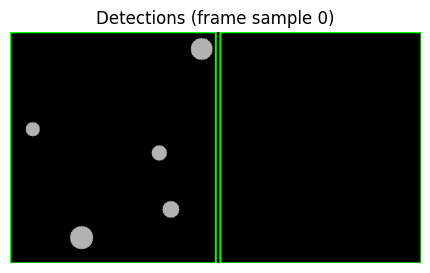

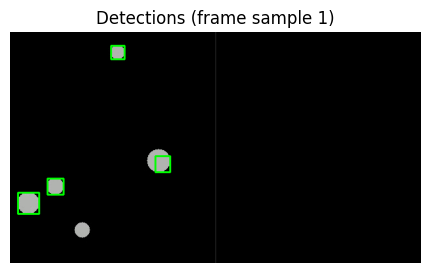

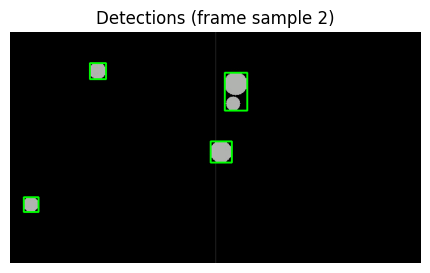

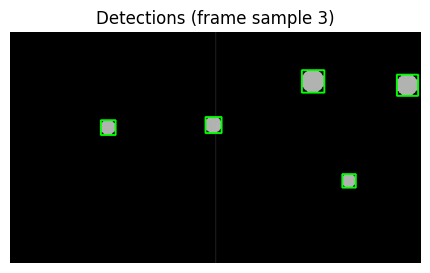

In [10]:

def draw_boxes_on_frame(frame_bgr, boxes, color=(0,255,0)):
    f = frame_bgr.copy()
    for (x,y,w,h) in boxes:
        cv2.rectangle(f, (x,y), (x+w, y+h), color, 2)
    return f

cap = cv2.VideoCapture(gt["video_path"])
show_idx = [0, 60, 120, 180]
idx = 0
frames_det = []
di = 0

while True and di < len(detections):
    ok, f = cap.read()
    if not ok:
        break
    if idx in show_idx:
        f2 = draw_boxes_on_frame(f, detections[di])
        frames_det.append(cv2.cvtColor(f2, cv2.COLOR_BGR2RGB))
    idx += 1
    di += 1

cap.release()

for i, f in enumerate(frames_det):
    plt.figure(figsize=(6,3))
    plt.title(f"Detections (frame sample {i})")
    plt.imshow(f)
    plt.axis("off")
    plt.show()



## 4) A Minimal Multi-Object Tracker (IoU + Lifecycles)

- Tracks have: id, bbox, centroid, age, hits, disappeared.
- Association: greedy IoU matching above a threshold.
- Unmatched detections start new tracks; unmatched tracks age and get removed.


In [11]:

def iou_xywh(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ax2, ay2 = ax+aw, ay+ah
    bx2, by2 = bx+bw, by+bh
    inter_w = max(0, min(ax2, bx2) - max(ax, bx))
    inter_h = max(0, min(ay2, by2) - max(ay, by))
    inter = inter_w * inter_h
    union = aw*ah + bw*bh - inter
    if union <= 0:
        return 0.0
    return inter / union

def centroid_xywh(b):
    x,y,w,h = b
    return (x + w/2.0, y + h/2.0)

from dataclasses import dataclass, field

@dataclass
class Track:
    id: int
    bbox: List[int]
    centroid: Tuple[float, float]
    age: int = 0
    hits: int = 0
    disappeared: int = 0
    count_state: Dict[str, bool] = field(default_factory=lambda: {"counted_lr": False})

class IoUTracker:
    def __init__(self, iou_thr=0.3, max_disappeared=15):
        self.iou_thr = iou_thr
        self.max_disappeared = max_disappeared
        self.tracks: Dict[int, Track] = {}
        self.next_id = 0

    def update(self, detections):
        if len(self.tracks) == 0:
            for d in detections:
                self._start_track(d)
            return self.tracks

        track_ids = list(self.tracks.keys())
        T = len(track_ids)
        D = len(detections)
        iou_mat = np.zeros((T, D), dtype=np.float32)
        for ti, tid in enumerate(track_ids):
            for di, det in enumerate(detections):
                iou_mat[ti, di] = iou_xywh(self.tracks[tid].bbox, det)

        matched_track = set()
        matched_det = set()

        while iou_mat.size > 0:
            ti, di = np.unravel_index(np.argmax(iou_mat), iou_mat.shape)
            best_iou = iou_mat[ti, di]
            if best_iou < self.iou_thr:
                break
            tid = track_ids[ti]
            if ti in matched_track or di in matched_det:
                iou_mat[ti, di] = -1
                continue
            self._update_track(tid, detections[di])
            matched_track.add(ti)
            matched_det.add(di)
            iou_mat[ti, :] = -1
            iou_mat[:, di] = -1

        for ti, tid in enumerate(track_ids):
            if ti not in matched_track:
                self.tracks[tid].disappeared += 1

        for tid in track_ids:
            if tid in self.tracks and self.tracks[tid].disappeared > self.max_disappeared:
                del self.tracks[tid]

        for di, det in enumerate(detections):
            if di not in matched_det:
                self._start_track(det)

        for tr in self.tracks.values():
            tr.age += 1
        return self.tracks

    def _start_track(self, det):
        c = centroid_xywh(det)
        tr = Track(id=self.next_id, bbox=det, centroid=c, age=1, hits=1, disappeared=0)
        self.tracks[self.next_id] = tr
        self.next_id += 1

    def _update_track(self, tid, det):
        tr = self.tracks[tid]
        tr.bbox = det
        tr.centroid = centroid_xywh(det)
        tr.hits += 1
        tr.disappeared = 0

tracker = IoUTracker(iou_thr=0.3, max_disappeared=20)
len(tracker.tracks)


0


## 5) Tracking + Line Counting (left ➜ right)

We check if a track’s centroid crosses the vertical line `x = W/2` from left to right.


In [12]:

def run_tracking_and_counting(video_path, detections_per_frame, line_x, save_vis_path="tracked_output.mp4"):
    cap = cv2.VideoCapture(video_path)
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(save_vis_path, fourcc, fps, (W,H))

    tracker = IoUTracker(iou_thr=0.3, max_disappeared=20)
    total_count_lr = 0
    last_x = {}

    frame_idx = 0
    while frame_idx < len(detections_per_frame):
        ok, frame = cap.read()
        if not ok:
            break
        boxes = detections_per_frame[frame_idx]
        tracks = tracker.update(boxes)

        cv2.line(frame, (line_x, 0), (line_x, H-1), (0,0,255), 2)

        for tid, tr in tracks.items():
            x,y,w,h = map(int, tr.bbox)
            cx, cy = tr.centroid
            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 2)
            cv2.circle(frame, (int(cx), int(cy)), 3, (255,255,255), -1)
            cv2.putText(frame, f"ID {tid}", (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv2.LINE_AA)

            prev_x = last_x.get(tid, cx)
            if prev_x < line_x and cx >= line_x and not tr.count_state["counted_lr"]:
                total_count_lr += 1
                tr.count_state["counted_lr"] = True
            last_x[tid] = cx

        cv2.putText(frame, f"Count L->R: {total_count_lr}", (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()
    return {"tracked_video": save_vis_path, "count_lr": total_count_lr}

result = run_tracking_and_counting(gt["video_path"], detections, int(gt["line_x"]))
result


{'tracked_video': 'tracked_output.mp4', 'count_lr': 4}

Peek a few frames from the tracked output.

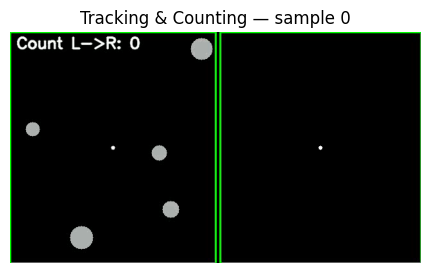

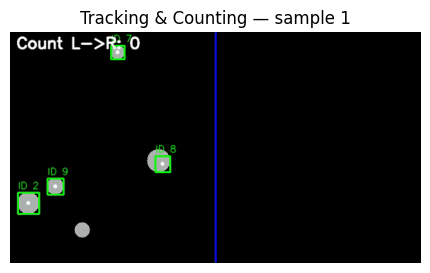

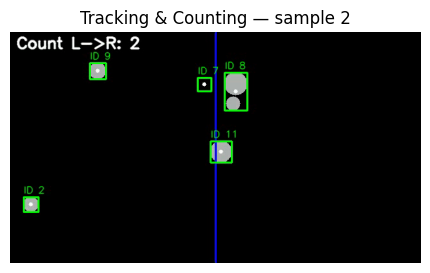

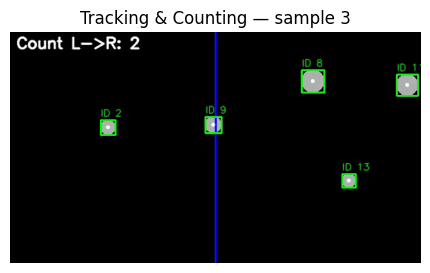

In [15]:

frames_tr = read_frames(result["tracked_video"], step=60, max_show=4)
for i, f in enumerate(frames_tr):
    plt.figure(figsize=(6,3))
    plt.title(f"Tracking & Counting — sample {i}")
    plt.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()



## 6) Quick Evaluation (Counting)

Compare predicted total left➜right crossings to ground truth.


Ground Truth L->R crossings: 5
Predicted L->R crossings   : 4
Absolute error             : 1


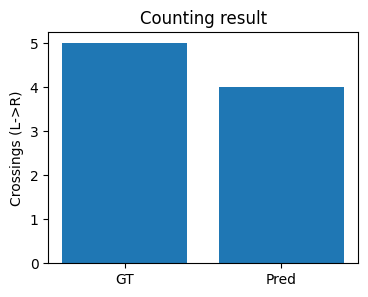

In [16]:

gt_total_lr = sum(gt["gt_crossings"].values())
pred_total_lr = result["count_lr"]
abs_err = abs(pred_total_lr - gt_total_lr)

print("Ground Truth L->R crossings:", gt_total_lr)
print("Predicted L->R crossings   :", pred_total_lr)
print("Absolute error             :", abs_err)

plt.figure(figsize=(4,3))
plt.title("Counting result")
plt.bar(["GT", "Pred"], [gt_total_lr, pred_total_lr])
plt.ylabel("Crossings (L->R)")
plt.show()



## 7) Exercises (Try it)

1. **Tune Background Subtraction**: change `history/varThreshold` and observe the effect.
2. **Swap Subtractor**:try `cv2.createBackgroundSubtractorKNN()`.
3. **Improve Association**: try nearest-centroid matching instead of IoU.
4. **Play with `max_disappeared`**: understand occlusion behavior.
5. **Direction-aware Counting**: add right➜left counter.
6. **ROI Counting**: count entries into a rectangular region.


### TODO A : KNN Subtractor

In [18]:

def detect_moving_objects_knn(video_path, min_area=80):
    fgbg = cv2.createBackgroundSubtractorKNN(history=200, dist2Threshold=400.0, detectShadows=True)
    cap = cv2.VideoCapture(video_path)
    detections_per_frame = []
    kernel = np.ones((3,3), np.uint8)

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        mask = fgbg.apply(frame)
        _, mask_bin = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY)
        mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel, iterations=2)
        mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel, iterations=2)
        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        boxes = []
        for c in contours:
            if cv2.contourArea(c) < min_area:
                continue
            x,y,w,h = cv2.boundingRect(c)
            boxes.append([x,y,w,h])
        detections_per_frame.append(boxes)

    cap.release()
    return detections_per_frame

# Example (uncomment to test):
det_knn = detect_moving_objects_knn(gt["video_path"])
res_knn = run_tracking_and_counting(gt["video_path"], det_knn, int(gt["line_x"]), save_vis_path="tracked_knn.mp4")
res_knn


{'tracked_video': 'tracked_knn.mp4', 'count_lr': 4}

### TODO B : Add Right ➜ Left Counting

In [19]:

def run_tracking_and_counting_bidirectional(video_path, detections_per_frame, line_x, save_vis_path="tracked_bidir.mp4"):
    cap = cv2.VideoCapture(video_path)
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(save_vis_path, fourcc, fps, (W,H))

    tracker = IoUTracker(iou_thr=0.3, max_disappeared=20)
    total_lr = 0
    total_rl = 0
    last_x = {}

    frame_idx = 0
    while frame_idx < len(detections_per_frame):
        ok, frame = cap.read()
        if not ok:
            break
        boxes = detections_per_frame[frame_idx]
        tracks = tracker.update(boxes)

        cv2.line(frame, (line_x, 0), (line_x, H-1), (0,0,255), 2)

        for tid, tr in tracks.items():
            x,y,w,h = map(int, tr.bbox)
            cx, cy = tr.centroid

            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 2)
            cv2.putText(frame, f"ID {tid}", (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv2.LINE_AA)

            prev_x = last_x.get(tid, cx)
            if prev_x < line_x and cx >= line_x and not tr.count_state.get("counted_lr", False):
                total_lr += 1
                tr.count_state["counted_lr"] = True
            if prev_x >= line_x and cx < line_x and not tr.count_state.get("counted_rl", False):
                total_rl += 1
                tr.count_state["counted_rl"] = True

            last_x[tid] = cx

        cv2.putText(frame, f"L->R: {total_lr}  R->L: {total_rl}", (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()
    return {"tracked_video": save_vis_path, "count_lr": total_lr, "count_rl": total_rl}

# Example (uncomment to test):
dets = detect_moving_objects_mog2(gt["video_path"])
res2 = run_tracking_and_counting_bidirectional(gt["video_path"], dets, int(gt["line_x"]))
res2


{'tracked_video': 'tracked_bidir.mp4', 'count_lr': 4, 'count_rl': 2}


## 8) Troubleshooting & Theory Bits

- Background subtraction may merge/split objects; IoU matching can switch IDs during overlaps.  
- Improvements (Prac. 20): detector (YOLO), Kalman + Hungarian (SORT), appearance embeddings (Deep SORT), ByteTrack.  
- Segmentation link (Prac. 21): masks give cleaner centroids and help during occlusion (instance tracking).

## 9) Wrap‑Up & Checklist

- Detection vs. tracking   
- Background subtraction   
- IoU-based tracking + counting   
- Simple evaluation   
- Bridge to Practicals 20 & 21 



---

**Next Practical →** **Practical 20: MOT with detector + Deep SORT/ByteTrack (YOLO + Kalman + Hungarian).**


---
📝 This practical was designed by **Dr. Zaid Al-Huda** to gives you a compact, hands-on intro to **object tracking & counting** with classical CV: generate a tiny synthetic video with ground truth, detect motion via background subtraction (MOG2/KNN), maintain IDs with a simple IoU tracker, draw a counting line, and compare counts to ground truth.